Part 1: Gradient descent
Define a series of functions to perform gradient descent to fit a linear regression model. All definitions should use matrix formulations. You will then use those to fit mpg from the predictors drat, wt, and am in the cars data. Recall that we found the coefficients analytically in the lin_reg_matrix notebook. We also did gradient descent on a simplified model in gradient_desc_exercise-no-dot notebook. Between the two of these you have most of what you need.

We want

Intercept not assumed equal to zero.

Multiple predictors; an arbitrary number

You will again have to:


Create a data matrix with ones in the first column, for the intercept.

Use matrix formulations to get the loss and gradient. These formulas are in the notebooks and handouts.

Keep track of loss in an array so you can plot.

Experiment with scaling the predictors or not. (Do not center the y values)                    ';;;;;;;;;;;;;;;

In [36]:
import numpy as np
def get_data_mat(X):
 ## This takes the data matrix and returns an numpy array of the data with ones in the first column.
    X_arr = np.asarray(X)
    ones = np.ones((X_arr.shape[0], 1))
    return np.hstack((ones, X_arr)) 
def predict(beta, X):
 ## This function returns the vector of predictions. It is the sum of the products of the 
 ## coefficients times the predictor values. Use matrix notation to vectorize. obligatory cat keyboard mark ;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
    return np.dot(X, beta)
def get_loss(beta, X, y):
 ## Gets the loss function. Use matrix notation
    predictions = predict(beta, X)
    errors = predictions - y
    return np.mean(errors ** 2)
    

In [37]:
def perform_gradient_descent(X, y, eta, num_iters):
    ## Arguments are data matrix X, targets y, learning rate eta, number of epochs num_iters
    X_b = get_data_mat(X)
    m, n = X_b.shape
    
    w_init = np.random.normal(loc=0.0, scale=0.1, size= X.shape[1] + 1)   
    w = [w_init]
    
    loss_init = get_loss(w_init, X_b, y)
    loss = [loss_init]


    #for a fixed number of iterations
    for i in range(num_iters):
       
        w_current = w[-1]
        
        # Gradient formula: (2/m) * X_b^T * (X_b * w - y)
        gradient = (2 / m) * X_b.T.dot(X_b.dot(w_current) - y)
        
        
        w_new = w_current - eta * gradient
        

        loss_new = get_loss(w_new, X_b, y)

        w.append(w_new)
        loss.append(loss_new)
        
    return w, loss 

Use your definition to train a model to predict mpg based on wt and disp for the cars data set.

Plot the loss vs epochs,

Experiment with different learning rates and number of epochs,

Find the RMSE of your model,

Compare the coefficients to those you obtained previously both analytically and using sklearn

In [38]:
import pandas as pd
cars = pd.read_csv('../data/cars.csv')

In [39]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Prepare features and target
X_raw = cars[['wt', 'disp']].values
y = cars['mpg'].values

# Standardize features for stable Gradient Descent
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

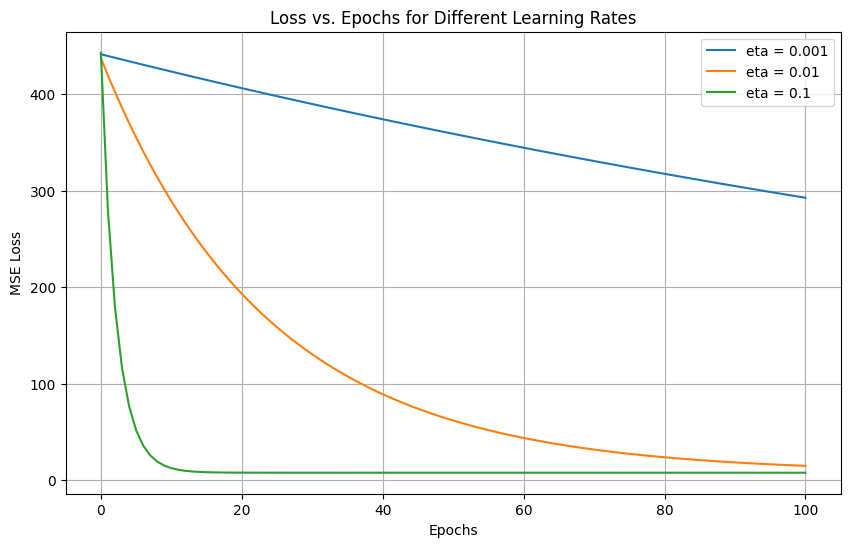

In [40]:
# 1. Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]
num_epochs = 100

plt.figure(figsize=(10, 6))

gd_results = {}
for eta in learning_rates:
    weights, losses = perform_gradient_descent(X_scaled, y, eta, num_epochs)
    gd_results[eta] = (weights, losses)
    plt.plot(range(num_epochs + 1), losses, label=f'eta = {eta}')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Loss vs. Epochs for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()



Our optimal learning rate is 0.1

In [41]:
# 2. Optimal Gradient Descent model evaluation (eta = 0.1)
best_eta = 0.1
best_weights, _ = gd_results[best_eta]
final_w_gd = best_weights[-1]

X_b = get_data_mat(X_scaled)
y_pred_gd = predict(final_w_gd, X_b)
rmse_gd = np.sqrt(mean_squared_error(y, y_pred_gd))

# 3. Analytical Solution (Normal Equation) on scaled features
# beta = (X^T * X)^(-1) * X^T * y
w_analytical = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
y_pred_analytical = predict(w_analytical, X_b)
rmse_analytical = np.sqrt(mean_squared_error(y, y_pred_analytical))

# 4. Sklearn Implementation on scaled features
sk_model = LinearRegression()
sk_model.fit(X_scaled, y)
w_sklearn = np.hstack(([sk_model.intercept_], sk_model.coef_))
y_pred_sk = sk_model.predict(X_scaled)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred_sk))

# 5. Print Comparison Table
comparison_df = pd.DataFrame({
    'Method': ['Gradient Descent (eta=0.1)', 'Analytical (Normal Eq)', 'sklearn LinearRegression'],
    'Intercept (w0)': [final_w_gd[0], w_analytical[0], w_sklearn[0]],
    'Weight Coef (w1)': [final_w_gd[1], w_analytical[1], w_sklearn[1]],
    'Disp Coef (w2)': [final_w_gd[2], w_analytical[2], w_sklearn[2]],
    'RMSE': [rmse_gd, rmse_analytical, rmse_sklearn]
})

print(comparison_df.to_string(index=False))

                    Method  Intercept (w0)  Weight Coef (w1)  Disp Coef (w2)     RMSE
Gradient Descent (eta=0.1)       20.090625         -3.169649       -2.219540 2.776610
    Analytical (Normal Eq)       20.090625         -3.227005       -2.162185 2.776478
  sklearn LinearRegression       20.090625         -3.227005       -2.162185 2.776478


Observations
Gradient Descent closely matches the exact analytical solution and sklearn 
All three methods produced the exact same intercept  
My analytical solution exactly matches sklearn